In [1]:
pip install datasets pandas matplotlib seaborn wordcloud nltk

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [13]:
import pandas as pd

base = "https://raw.githubusercontent.com/tfs4/liar_dataset/master/"

train_df = pd.read_csv(base + "train.tsv", sep='\t', header=None,
    names=['id','label','statement','subject','speaker','job','state',
           'party','barely_true','false','half_true','mostly_true',
           'pants_fire','context'])

test_df = pd.read_csv(base + "test.tsv", sep='\t', header=None,
    names=['id','label','statement','subject','speaker','job','state',
           'party','barely_true','false','half_true','mostly_true',
           'pants_fire','context'])

val_df = pd.read_csv(base + "valid.tsv", sep='\t', header=None,
    names=['id','label','statement','subject','speaker','job','state',
           'party','barely_true','false','half_true','mostly_true',
           'pants_fire','context'])

print("Train size:", len(train_df))
print("Labels:\n", train_df['label'].value_counts())

def simplify_label(label):
    fake_labels = ['false', 'pants-fire', 'barely-true']
    return 0 if label in fake_labels else 1

train_df['binary_label'] = train_df['label'].apply(simplify_label)
test_df['binary_label']  = test_df['label'].apply(simplify_label)
val_df['binary_label']   = val_df['label'].apply(simplify_label)

print("\nBinary distribution:\n", train_df['binary_label'].value_counts())

train_df[['statement','binary_label']].to_csv('train.csv', index=False)
test_df[['statement','binary_label']].to_csv('test.csv', index=False)
val_df[['statement','binary_label']].to_csv('val.csv', index=False)
print("\n✅ Done! train.csv, test.csv, val.csv are ready.")

Train size: 10240
Labels:
 label
half-true      2114
false          1995
mostly-true    1962
true           1676
barely-true    1654
pants-fire      839
Name: count, dtype: int64

Binary distribution:
 binary_label
1    5752
0    4488
Name: count, dtype: int64

✅ Done! train.csv, test.csv, val.csv are ready.


Average text length: 106.91875
Max: 3192
Min: 11


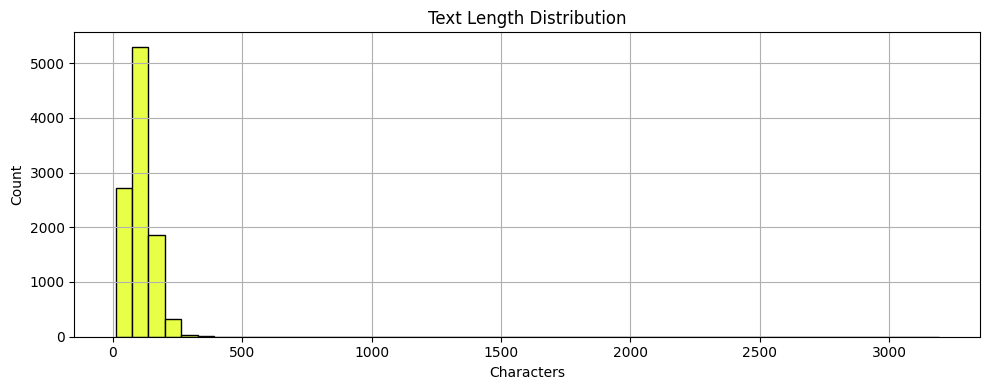

In [14]:
train_df['text_len'] = train_df['statement'].apply(len)
print("Average text length:", train_df['text_len'].mean())
print("Max:", train_df['text_len'].max())
print("Min:", train_df['text_len'].min())

plt.figure(figsize=(10,4))
train_df['text_len'].hist(bins=50, color='#e8ff47', edgecolor='black')
plt.title('Text Length Distribution')
plt.xlabel('Characters')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('text_length_dist.png')
plt.show()

In [15]:
train_df[['statement','binary_label']].to_csv('train.csv', index=False)
test_df[['statement','binary_label']].to_csv('test.csv', index=False)
val_df[['statement','binary_label']].to_csv('val.csv', index=False)
print("✅ Saved train.csv, test.csv, val.csv")

✅ Saved train.csv, test.csv, val.csv
